# heatguard_cell_feature_scored — 피처 엔지니어링 및 점수화

**프로젝트:** HeatGuardAI — 서울시 폭염 대응 쿨링포그 설치 추천 시스템

**목적:** 원시 환경/인구 데이터를 **0~1 점수(score)**로 변환하여 분석용 데이터셋을 생성합니다.

**파이프라인:**
1. 데이터 로드 · 불필요 컬럼 제거
2. **SUHII** (도시열섬강도) 계산 → MinMax 스케일링
3. **체감온도** (`ta_chi`) → MinMax 스케일링
4. **유동인구** (`bus_pop_sum`) → IDW 보간 → log1p → MinMax 스케일링
5. **식생지수** (`ndvi_mean`) → 물리범위 클리핑 → IQR 클리핑 → MinMax 스케일링
6. **취약계층지수** (`vulnerable_index`) → MinMax 스케일링
7. 최종 컬럼 선택 · 이름 표준화 · CSV 저장

**입력:** `merged_data/gmm_feature_merged.csv`
**출력:** `data/processed/heatguard_cell_feature_scored.csv`

| 원시 변수 | 변환 방법 | 점수 컬럼 |
|-----------|-----------|-----------|
| `LST_C` → `Suhii` | LST - 20th%ile → MinMax | `suhii_score` |
| `ta_chi` | MinMax | `apparent_temp_score` |
| `bus_pop_sum` | IDW 보간(0값) → log1p → MinMax | `bus_flow_score` |
| `ndvi_mean` | 물리/IQR 클리핑 → MinMax | `ndvi_score` |
| `vulnerable_index` | MinMax | `vulnerable_score` |

## 0. 라이브러리 · 헬퍼 함수

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.spatial import cKDTree
from sklearn.preprocessing import MinMaxScaler

In [2]:
def describe_dataframe(df, percentiles=(0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99)):
    """수치형 컬럼에 대해 확장 통계(결측, 이상치 비율 등)를 반환합니다."""
    rows = []
    for col in df.columns:
        s = df[col]
        info = {"column": col, "dtype": s.dtype, "count": s.count(),
                "missing": s.isna().sum(), "missing%": s.isna().mean()}
        if pd.api.types.is_numeric_dtype(s):
            desc = s.describe(percentiles=percentiles)
            info.update({k: desc.get(k) for k in ["mean", "std", "min", "25%", "50%", "75%", "max"]})
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            iqr = q3 - q1
            info["outlier%"] = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean() if iqr > 0 else 0
        rows.append(info)
    return pd.DataFrame(rows).set_index("column")


def idw_interpolation(known_xy, known_values, target_xy, k=5, power=2):
    """Inverse Distance Weighting(IDW) 공간 보간."""
    tree = cKDTree(known_xy)
    dist, idx = tree.query(target_xy, k=k)
    weights = 1 / (dist ** power + 1e-6)
    values = known_values[idx]
    return np.sum(weights * values, axis=1) / np.sum(weights, axis=1)

In [16]:
# ── 전역 설정 ──
# 노트북 13(merge_cellid_admin_lst_suhii)이 ../data_processed/... 에 저장하므로 동일한 기준 경로 사용
INPUT_PATH  = "../data_processed/processed/merged/merged_data.csv"
OUTPUT_PATH = "../data_processed/processed/merged/heatguard_cell_feature_scored.csv"

# SUHII 기준 퍼센타일
SUHII_REF_PERCENTILE = 20

# 최종 컬럼 매핑 (원본 → 표준화된 이름)
FINAL_COLS = {
    "cell_id":                  "cell_id",
    "center_lat":               "center_lat",
    "center_lon":               "center_lon",
    "gu_name":                    "gu_name",
    "dong_name":                   "dong_name",
    "suhii":                    "suhii",
    "suhii_scaled":             "suhii_score",
    "ta_chi":                   "apparent_temp",
    "ta_chi_scaled":            "apparent_temp_score",
    "bus_pop_scaled":            "bus_flow_score",
    "ndvi":                "ndvi",
    "ndvi_scaled":              "ndvi_score",
    "vulnerable_scaled":  "vulnerable_score",
}

## 1. 데이터 로드 및 정리

In [4]:
df = pd.read_csv(INPUT_PATH)

# 불필요 컬럼 제거
cols_to_drop = ["Unnamed: 0", ".geo", "max_lat", "max_lon", "min_lat", "min_lon", "EMD_KOR_NM", "EMD_CD"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"행 수: {len(df):,}")
print(f"컬럼: {list(df.columns)}")
df.head()

행 수: 92,398
컬럼: ['cell_id', 'center_lat', 'center_lon', 'gu_name', 'dong_name', 'lst_c', 'suhii', 'ta_chi', 'bus_pop', 'vulnerable', 'ndvi']


,cell_id,center_lat,center_lon,gu_name,dong_name,lst_c,suhii,ta_chi,bus_pop,vulnerable,ndvi
0,1411415045163,37.552140,126.789567,강서구,공항동,32.806552,1.501585,30.55,0.0,1.587958,0.345653
1,1411415045164,37.552852,126.789567,강서구,공항동,34.517906,3.212939,30.55,0.0,1.587958,0.132720
2,1411415045165,37.553564,126.789567,강서구,공항동,35.744976,4.440008,30.55,0.0,1.587958,0.097017
3,1411425045158,37.548579,126.790465,강서구,공항동,26.472243,-4.832725,30.51,0.0,1.587958,0.615040
4,1411425045159,37.549291,126.790465,강서구,공항동,26.476739,-4.828229,30.51,0.0,1.587958,0.619014


## 2. SUHII (도시열섬강도) 점수화

**SUHII** = 각 셀의 지표면온도(LST_C) - 전체 20th percentile 기준온도
→ MinMax 스케일링으로 0~1 범위로 변환합니다.

In [5]:
# ── MinMax 스케일링 ──
scaler = MinMaxScaler()
df["suhii_scaled"] = scaler.fit_transform(df[["suhii"]])

describe_dataframe(df[["suhii", "suhii_scaled"]])

,dtype,count,missing,missing%,mean,std,min,25%,50%,75%,max,outlier%
column,,,,,,,,,,,,
suhii,float64,91765,633,0.006851,4.396038,4.840204,-14.936747,1.175799,5.410726,7.981077,17.208022,0.010303
suhii_scaled,float64,91765,633,0.006851,0.601429,0.150575,0.000000,0.501249,0.632995,0.712957,1.000000,0.010303


## 3. 체감온도 (`ta_chi`) 점수화

체감온도를 MinMax 스케일링으로 0~1 범위로 변환합니다.

In [6]:
scaler = MinMaxScaler()
df["ta_chi_scaled"] = scaler.fit_transform(df[["ta_chi"]])

describe_dataframe(df[["ta_chi", "ta_chi_scaled"]])

,dtype,count,missing,missing%,mean,std,min,25%,50%,75%,max,outlier%
column,,,,,,,,,,,,
ta_chi,float64,92398,0,0.0,30.185219,0.543691,27.49,29.990000,30.300000,30.420000,32.65,0.086809
ta_chi_scaled,float64,92398,0,0.0,0.522329,0.105366,0.00,0.484496,0.544574,0.567829,1.00,0.086809


## 4. 유동인구 (`bus_pop_sum`) 보간 및 점수화

1. **IDW(역거리 가중) 보간**: bus_pop_sum=0인 셀에 주변 5개 셀의 가중 평균을 할당
2. **log1p 변환**: 극단적 편포 완화
3. **MinMax 스케일링**: 0~1 범위로 변환

In [8]:
# ── 좌표 투영 (위경도 → UTM-K 미터 단위) ──
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["center_lon"], df["center_lat"]),
    crs="EPSG:4326",
).to_crs(epsg=5179)

df["_x"] = gdf.geometry.x
df["_y"] = gdf.geometry.y

# ── IDW 보간 (bus_pop_sum == 0인 셀만) ──
df_known  = df[df["bus_pop"] > 0]
df_target = df[df["bus_pop"] == 0].copy()

interp_values = idw_interpolation(
    known_xy=df_known[["_x", "_y"]].values,
    known_values=df_known["bus_pop"].values,
    target_xy=df_target[["_x", "_y"]].values,
    k=5, power=2,
)
df_target["bus_pop_interp"] = interp_values

# ── 보간값 병합 ──
df["bus_pop_interp"] = df["bus_pop"].astype(float)
df.loc[df["bus_pop"] == 0, "bus_pop_interp"] = df_target["bus_pop_interp"].values

# ── log1p + MinMax ──
x_log = np.log1p(df["bus_pop_interp"].clip(lower=0))
scaler = MinMaxScaler()
df["bus_pop_scaled"] = scaler.fit_transform(x_log.to_frame())

# ── 임시 컬럼 제거 ──
df = df.drop(columns=["_x", "_y"])

describe_dataframe(df[["bus_pop", "bus_pop_interp", "bus_pop_scaled"]])

,dtype,count,missing,missing%,mean,std,min,25%,50%,75%,max,outlier%
column,,,,,,,,,,,,
bus_pop,float64,92398,0,0.0,13928.067159,46288.318231,0.00,0.000000,0.000000,3516.245000,1591331.67,0.210773
bus_pop_interp,float64,92398,0,0.0,39324.284220,54376.421102,3.67,9177.929309,23056.017721,48806.670000,1591331.67,0.075575
bus_pop_scaled,float64,92398,0,0.0,0.655629,0.101901,0.00,0.595302,0.667605,0.726473,1.00,0.018420


## 5. 식생지수 (`ndvi_mean`) 점수화

1. **물리 범위 클리핑**: [-1, 1]
2. **IQR 기반 클리핑**: 이상치 영향 완화 (제거하지 않고 클리핑)
3. **MinMax 스케일링**: 0~1 범위로 변환

In [10]:
# ── 물리 범위 + IQR 클리핑 ──
ndvi = df["ndvi"].clip(-1, 1)
q1, q3 = ndvi.quantile([0.25, 0.75])
iqr = q3 - q1
ndvi_clipped = ndvi.clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

# ── MinMax 스케일링 ──
scaler = MinMaxScaler()
df["ndvi_scaled"] = scaler.fit_transform(ndvi_clipped.to_frame())

describe_dataframe(df[["ndvi", "ndvi_scaled"]])

,dtype,count,missing,missing%,mean,std,min,25%,50%,75%,max,outlier%
column,,,,,,,,,,,,
ndvi,float64,91766,632,0.00684,0.441028,0.259419,-26.556906,0.250198,0.389720,0.657074,1.397439,0.000823
ndvi_scaled,float64,91766,632,0.00684,0.589489,0.173796,0.000000,0.448722,0.551303,0.747870,1.000000,0.000000


## 6. 취약계층지수 (`vulnerable_index`) 점수화

MinMax 스케일링으로 0~1 범위로 변환합니다.

In [12]:
scaler = MinMaxScaler()
df["vulnerable_scaled"] = scaler.fit_transform(df[["vulnerable"]])

describe_dataframe(df[["vulnerable", "vulnerable_scaled"]])

,dtype,count,missing,missing%,mean,std,min,25%,50%,75%,max,outlier%
column,,,,,,,,,,,,
vulnerable,float64,92398,0,0.0,0.245184,1.667943,-3.279769,-0.946654,-0.076743,1.218336,7.538499,0.012121
vulnerable_scaled,float64,92398,0,0.0,0.325833,0.154178,0.000000,0.215664,0.296076,0.415788,1.000000,0.012121


## 7. 점수 분포 시각화

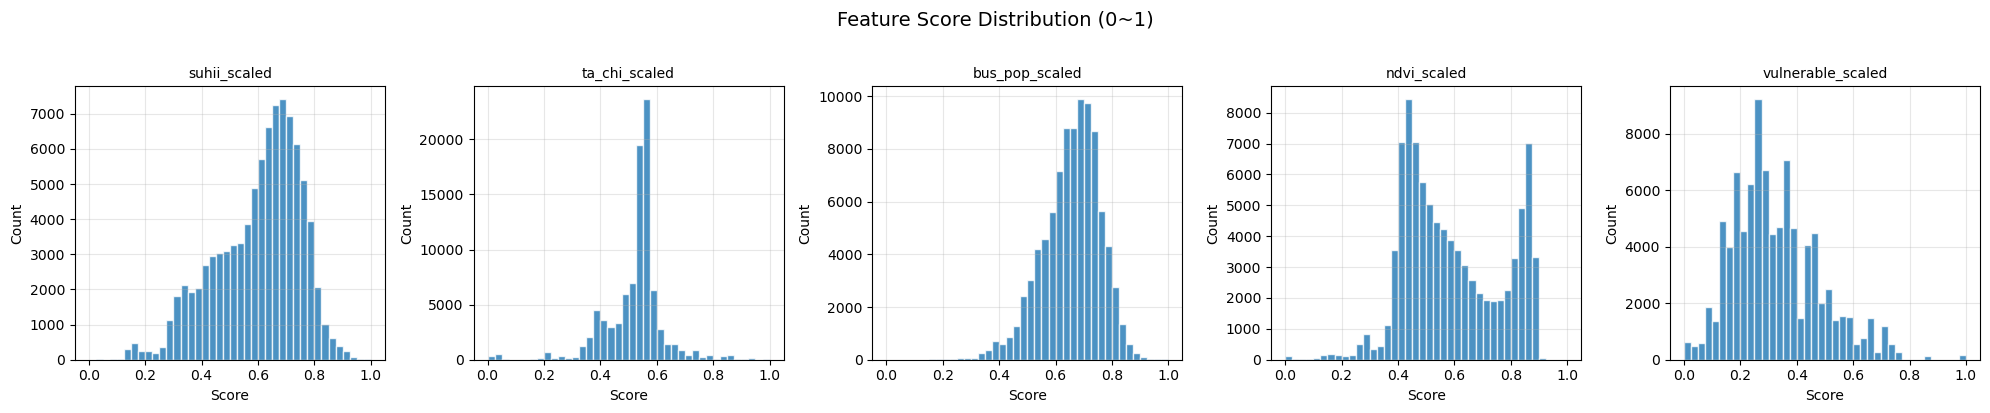

In [14]:
score_cols = ["suhii_scaled", "ta_chi_scaled", "bus_pop_scaled", "ndvi_scaled", "vulnerable_scaled"]
fig, axes = plt.subplots(1, len(score_cols), figsize=(20, 4))

for ax, col in zip(axes, score_cols):
    ax.hist(df[col].dropna(), bins=40, edgecolor="white", alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.3)

plt.suptitle("Feature Score Distribution (0~1)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. 최종 컬럼 선택 및 CSV 저장

In [17]:
# ── 최종 컬럼 선택 + 이름 표준화 ──
df_processed = df[list(FINAL_COLS.keys())].rename(columns=FINAL_COLS).copy()

print(f"최종 데이터: {len(df_processed):,}행 × {len(df_processed.columns)}열")
print(f"컬럼: {list(df_processed.columns)}")

# ── CSV 저장 ──
df_processed.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
print(f"\nSaved: {OUTPUT_PATH}")
df_processed.head(10)

최종 데이터: 92,398행 × 13열
컬럼: ['cell_id', 'center_lat', 'center_lon', 'gu_name', 'dong_name', 'suhii', 'suhii_score', 'apparent_temp', 'apparent_temp_score', 'bus_flow_score', 'ndvi', 'ndvi_score', 'vulnerable_score']

Saved: ../data_processed/processed/merged/heatguard_cell_feature_scored.csv


,cell_id,center_lat,center_lon,gu_name,dong_name,suhii,suhii_score,apparent_temp,apparent_temp_score,bus_flow_score,ndvi,ndvi_score,vulnerable_score
0,1411415045163,37.552140,126.789567,강서구,공항동,1.501585,0.511384,30.55,0.593023,0.658269,0.345653,0.518903,0.449954
1,1411415045164,37.552852,126.789567,강서구,공항동,3.212939,0.564623,30.55,0.593023,0.657479,0.132720,0.362348,0.449954
2,1411415045165,37.553564,126.789567,강서구,공항동,4.440008,0.602797,30.55,0.593023,0.656581,0.097017,0.336099,0.449954
3,1411425045158,37.548579,126.790465,강서구,공항동,-4.832725,0.314329,30.51,0.585271,0.678467,0.615040,0.716965,0.449954
4,1411425045159,37.549291,126.790465,강서구,공항동,-4.828229,0.314469,30.51,0.585271,0.678324,0.619014,0.719887,0.449954
5,1411425045160,37.550004,126.790465,강서구,공항동,-3.930723,0.342389,30.51,0.585271,0.663584,0.633650,0.730648,0.449954
6,1411425045161,37.550716,126.790465,강서구,공항동,-2.382843,0.390543,30.51,0.585271,0.663230,0.567629,0.682107,0.449954
7,1411425045162,37.551428,126.790465,강서구,공항동,-0.139431,0.460334,30.55,0.593023,0.662809,0.339904,0.514676,0.449954
8,1411425045163,37.552140,126.790465,강서구,공항동,1.807327,0.520896,30.55,0.593023,0.662309,0.150532,0.375444,0.449954
9,1411425045164,37.552852,126.790465,강서구,공항동,2.802776,0.551863,30.55,0.593023,0.658061,0.093055,0.333186,0.449954
